<a href="https://colab.research.google.com/github/Ship-N/Colab/blob/assignments/Semantic_Segmentationipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.train import Feature, BytesList, Int64List, Features, Example
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from IPython.display import Image
from tensorflow import keras

# Step 1- Dataset preparation:

## Load Files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

file_id = "1NR0FoSDCnlw8m-j-CnsZrBBaF85hKYk9"
output_file = "downloaded_file.zip"

!gdown --id $file_id -O $output_file

print(f"File {output_file} downloaded successfully!")

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1NR0FoSDCnlw8m-j-CnsZrBBaF85hKYk9
From (redirected): https://drive.google.com/uc?id=1NR0FoSDCnlw8m-j-CnsZrBBaF85hKYk9&confirm=t&uuid=f0ca3c61-8e6e-4558-8fca-73312a0e1b2b
To: /content/downloaded_file.zip
100% 4.93G/4.93G [00:36<00:00, 137MB/s]
File downloaded_file.zip downloaded successfully!


In [ ]:
# Create a folder to extract the files
extract_path = "/content/extracted_files"
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
!unzip -q "$output_file" -d "$extract_path"

print(f"File extracted to {extract_path}")

File extracted to /content/extracted_files


In [ ]:
# List files in the extracted folder
extracted_files = os.listdir(extract_path + '/Potsdam-GeoTif')
print("Extracted files:")
extracted_files

Extracted files:


['0000030912-0000035840.tif',
 '0000022176-0000042112.tif',
 '0000025984-0000014112.tif',
 '0000017696-0000038976.tif',
 '0000035168-0000002688.tif',
 '0000026880-0000025312.tif',
 '0000003360-0000038752.tif',
 '0000026880-0000009632.tif',
 '0000007168-0000031136.tif',
 '0000027328-0000014112.tif',
 '0000017024-0000033824.tif',
 '0000032032-0000006048.tif',
 '0000030912-0000033600.tif',
 '0000035840-0000002688.tif',
 '0000024416-0000027328.tif',
 '0000009184-0000028896.tif',
 '0000025312-0000021952.tif',
 '0000007392-0000041664.tif',
 '0000000448-0000028448.tif',
 '0000025984-0000022848.tif',
 '0000034048-0000029120.tif',
 '0000026432-0000030464.tif',
 '0000034720-0000019264.tif',
 '0000031808-0000021056.tif',
 '0000008288-0000034944.tif',
 '0000028448-0000026656.tif',
 '0000006720-0000031136.tif',
 '0000020384-0000040096.tif',
 '0000001568-0000028896.tif',
 '0000001792-0000035392.tif',
 '0000034048-0000015232.tif',
 '0000022176-0000038080.tif',
 '0000034048-0000009632.tif',
 '00000331

## Visualize_GeoTiff

In [ ]:
import glob

!pip install rasterio
import rasterio as rio
from rasterio.transform import xy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 84.7 MB/s eta 0:00:00


Text(0.5, 1.0, 'Input image')

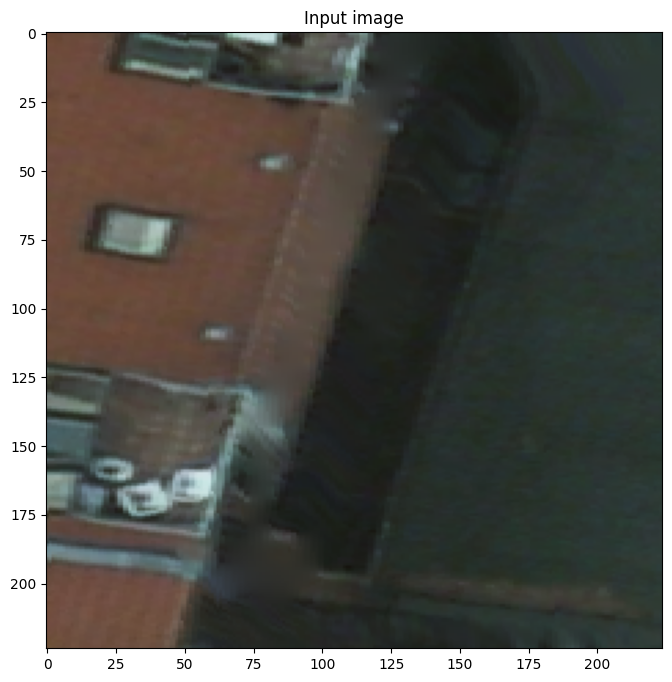

In [ ]:
blob = extract_path + '/Potsdam-GeoTif' +  '/0000030464-0000043904.tif'

img = rio.open(blob)
img_array = img.read()
imtransform = img.transform
nRows = img_array.shape[1]
ncols = img_array.shape[2]
Bands = img_array.shape[0]

img_array = img_array.reshape(Bands, nRows*ncols).T
img_array = img_array.reshape( nRows,ncols, Bands)

plt.figure(figsize=(24,8))

plt.imshow(img_array[:,:,0:3]/255)
# plt.imshow(img_array[:,:,5:6]/255)
# plt.imshow(img_array[:,:,5:6]/255)
plt.title('Input image')

## Split 5 folds

In [ ]:
# select 5000 from all the data
selected_files = random.sample(extracted_files, 5000)

In [ ]:
def load_geotiff(file_path):
    with rio.open(file_path) as dataset:
        image = dataset.read()
    return image

def create_tf_example(image):
    image_shape = image.shape  # (6, H, W)

    input_features = np.transpose(image[:5, :, :], (1, 2, 0))
    target_label = image[5, :, :]

    input_features_raw = input_features.tobytes()
    target_label_raw = target_label.astype(np.int64).tobytes()

    feature = {
        'image': Feature(bytes_list=BytesList(value=[input_features_raw])),
        'label': Feature(bytes_list=BytesList(value=[target_label_raw])),
        'height': Feature(int64_list=Int64List(value=[image_shape[1]])),
        'width': Feature(int64_list=Int64List(value=[image_shape[2]])),
        'channels': Feature(int64_list=Int64List(value=[5]))
    }
    return Example(features=Features(feature=feature))

def save_tf_record(file_path, file_list, dataset_dir):
    with tf.io.TFRecordWriter(file_path) as writer:
        for file_name in file_list:
            image_path = os.path.join(dataset_dir, file_name)
            image = load_geotiff(image_path)
            tf_example = create_tf_example(image)
            writer.write(tf_example.SerializeToString())
    print(f"Saved: {file_path}")

folds = [selected_files[i * 1000: (i + 1) * 1000] for i in range(0, 5)]


for i in range(0, 5):
    save_tf_record(os.path.join(extract_path, f"fold_{i}.tfrecord"), folds[i], extract_path + '/Potsdam-GeoTif')

Saved: /content/extracted_files/fold_0.tfrecord
Saved: /content/extracted_files/fold_1.tfrecord
Saved: /content/extracted_files/fold_2.tfrecord
Saved: /content/extracted_files/fold_3.tfrecord
Saved: /content/extracted_files/fold_4.tfrecord


In [ ]:
def parse_tfrecord(example, has_elevation=False):
    feature_description = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.string),
        "height": tf.io.FixedLenFeature([], tf.int64),
        "width": tf.io.FixedLenFeature([], tf.int64),
        "channels": tf.io.FixedLenFeature([], tf.int64),
    }

    parsed = tf.io.parse_single_example(example, feature_description)

    height = parsed["height"]
    width = parsed["width"]
    channels = parsed["channels"]

    image = tf.io.decode_raw(parsed["image"], tf.float32)
    image = tf.reshape(image, (height, width, channels))

    rgb = image[:, :, :3]/255.0
    ir = image[:, :, 3:4]/255.0

    if has_elevation:
        elevation = image[:, :, 4:5]/255.0
        image = tf.concat([rgb, ir, elevation], axis=-1)
    else:
        image = tf.concat([rgb, ir], axis=-1)

    label = tf.io.decode_raw(parsed["label"], tf.int64)
    label = tf.reshape(label, (height, width))
    label = tf.cast(label, tf.int32)
    label = tf.one_hot(label, depth=6)

    return image, label

def load_dataset(filenames, batch_size, has_elevation=False, augment=True):
    dataset = tf.data.TFRecordDataset(filenames)
    dataset = dataset.map(lambda example: parse_tfrecord(example, has_elevation), num_parallel_calls=tf.data.experimental.AUTOTUNE)
    dataset = dataset.shuffle(1000).batch(batch_size, drop_remainder=True).prefetch(tf.data.experimental.AUTOTUNE)

    return dataset

# Step 3- Training an Encoder-Decoder model

In [ ]:
train_tfrecords = [f"{extract_path}/fold_0.tfrecord",
                   f"{extract_path}/fold_1.tfrecord",
                   f"{extract_path}/fold_2.tfrecord"]
val_tfrecord = f"{extract_path}/fold_3.tfrecord"
test_tfrecord = f"{extract_path}/fold_4.tfrecord"

EPOCHS = 20

In [ ]:
def model_3():
    inputs = Input(shape=(224, 224, 5))

    conv1 = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    pool1 = MaxPooling2D(pool_size=(2,2))(conv1)

    conv2 = Conv2D(64, (3,3), activation='relu', padding='same')(pool1)
    pool2 = MaxPooling2D(pool_size=(2,2))(conv2)

    conv3 = Conv2D(64, (3,3), activation='relu', padding='same')(pool2)

    convt1 = Conv2DTranspose(64, (3,3), strides=(2,2), padding='same', activation='relu')(conv3)
    concat1 = Concatenate()([convt1, conv2])

    convt2 = Conv2DTranspose(32, (3,3), strides=(2,2), padding='same', activation='relu')(concat1)
    concat2 = Concatenate()([convt2, conv1])

    outputs = Conv2D(6, (3,3), activation='softmax', padding='same')(concat2)

    model = Model(inputs, outputs)
    return model

In [ ]:
train_dataset = load_dataset(train_tfrecords, 32, True)
val_dataset = load_dataset([val_tfrecord], 32, True)
test_dataset = load_dataset([test_tfrecord], 32, True)

In [ ]:
print("Num GPUs Available:", len(tf.config.experimental.list_physical_devices('GPU')))
tf.config.list_physical_devices()

Num GPUs Available: 0


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:TPU_SYSTEM:0', device_type='TPU_SYSTEM'),
 PhysicalDevice(name='/physical_device:TPU:0', device_type='TPU'),
 PhysicalDevice(name='/physical_device:TPU:1', device_type='TPU'),
 PhysicalDevice(name='/physical_device:TPU:2', device_type='TPU'),
 PhysicalDevice(name='/physical_device:TPU:3', device_type='TPU'),
 PhysicalDevice(name='/physical_device:TPU:4', device_type='TPU'),
 PhysicalDevice(name='/physical_device:TPU:5', device_type='TPU'),
 PhysicalDevice(name='/physical_device:TPU:6', device_type='TPU'),
 PhysicalDevice(name='/physical_device:TPU:7', device_type='TPU')]

In [ ]:
model = model_3()
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_loss')

history = model.fit(train_dataset, validation_data=val_dataset, epochs=20, callbacks=[checkpoint_cb])
best_model = load_model("best_model_3.h5")

Epoch 1/20


NotFoundError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.11/dist-packages/ipy

In [ ]:

plot_model(model, to_file="model_structure.png", show_shapes=True, show_layer_names=True)

Image("model_structure.png")

In [ ]:
test_loss, test_acc = best_model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.show()